# Predictive NFL Success

**Goal:** Identify which pre-draft metrics (college production, combine athleticism) 
best predict NFL success for wide receivers.

This analysis will help answer questions like:
- Do elite WRs share common athletic thresholds?
- Is college production or combine testing more predictive?
- Can we identify "bust" warning signs before the draft?

In this notebook, I will use a blend of college production and combine production to try and find a correlation of which receivers become successful in the NFL. 
<br><br>
To do so, I will use similar metrics to those that I used in my first notebook, 01_draft_hit_rate. <br><br>

This Notebook is important to me for two reasons:
1. I want to determine if my criteria/metrics for tiers of receivers have merit
2. I want to determine which stats are determining factors of my metrics

<br>

As a reminder, this is the criteria:<br>

| Level | Criteria | 
| :--- | :--- |
| Elite | 2+ seasons with elite YDS (1200+), <br>OR 2+ seasons with elite TDs (10+), <br>OR 1 season with elite YDS AND 1 season of elite TDs |
| Hit | 2+ seasons with hit YDS (800-1199),  <br>OR 2+ seasons with hit TDs (6-9), <br>OR 1 season with elite YDS AND 1 season of hit TDs<br>OR 1 season with hit YDS AND 1 season of role TDs | 
| Role | 2+ seasons with role YDS (400-799), <br>OR 2+ seasons with role TDs (3-5), <br>OR 1 season with hit YDS AND 1 season of role TDs<br>OR 1 season with role YDS AND 1 season of hit TDs | 
| Bust | Never hit 400 yards OR never in NextGen | 

##### Recent Draftees (2024-2025):
**2024**
| Level | Criteria | 
| :--- | :--- |
| Elite | 2+ Elite YDS OR tds, <br>OR 1 Elite YDS AND 1 Elite tds |
| HIT | 1 Elite YDS AND 1 Hit YDS, <br>OR 1 Elite TDs AND 1 Hit TDs, <br>OR 1 Elite YDS AND 1 Hit TDs,<br>OR 1 Elite TDs and 1 Hit YDS |
| Too Soon | 1 Hit yds OR tds (or anything below) |

**2025**
| Level | Criteria | 
| :--- | :--- |
| Elite | Elite YDS AND TDs |
| HIT | Elite YDS AND Hit TDs, <br>OR Hit YDS AND Elite TDs |
| Too Soon | Anything Else |

***

### Data Sources
- **College stats**: 2017-2025 (YPG, Y/R, TDs, Conference)
- **Combine data**: 2017-2025 (40 time, Vertical, Bench, 3-cone)
- **NFL outcomes**: Tier classifications from Notebook 01

### First Steps
First I will need to run my query again to find which receivers fall into each category. This query adds logic from my first notebook while also adding extra varible to test, including combine and college statistics. 

In [7]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
WITH player_tiers AS (
    -- checking for number of each type of season, total seasons (YOUR EXISTING CODE)
    SELECT 
        n.NAME,
        SUM(CASE WHEN n.YDS >= 1200 THEN 1 ELSE 0 END) as elite_yard_seasons,
        SUM(CASE WHEN n.YDS >= 800 THEN 1 ELSE 0 END) as hit_yard_seasons,
        SUM(CASE WHEN n.YDS >= 400 THEN 1 ELSE 0 END) as role_yard_seasons,
        SUM(CASE WHEN n.TD >= 10 THEN 1 ELSE 0 END) as elite_td_seasons,
        SUM(CASE WHEN n.TD >= 6 THEN 1 ELSE 0 END) as hit_td_seasons,
        SUM(CASE WHEN n.TD >= 3 THEN 1 ELSE 0 END) as role_td_seasons,
        COUNT(DISTINCT n.YEAR) as seasons_in_nextgen
    FROM nextgen n
    WHERE n.POS = 'WR'
    GROUP BY n.NAME
),
college_stats AS (
    -- aggregate college stats per player
    SELECT 
        c.Player,
        AVG(c.RecYperG) as college_ypg,
        AVG(c.YperR) as yards_per_catch,
        MAX(c.RecTD) as peak_college_td,
        c.Conf,
        CASE 
            WHEN c.Conf IN ('SEC', 'Big Ten') THEN 'Top 2 Conferences'
            WHEN c.Conf IN ('ACC', 'Big 12', 'Pac-12') THEN 'Power 5'
            ELSE 'Other'
        END as conference_tier
    FROM college c
    GROUP BY c.Player
),
combine_stats AS (
    -- get combine data per player
    SELECT 
        Player,
        `40yd` as forty_time,
        Vertical,
        Bench,
        `Broad Jump` as broad_jump,
        `3Cone` as cone,
        Shuttle
    FROM combine
    WHERE `40yd` IS NOT NULL AND `40yd` > 0
),
drafted_players AS (
    -- get all drafted WRs 2017-2025 with their tiers (YOUR EXISTING CODE)
    SELECT 
        d.Name as Player,
        d.Year as draft_year,
        d.Round,
        d.Player as Pick,    
        CASE 
            -- ELITE TIER
            WHEN pt.elite_yard_seasons >= 2 OR pt.elite_td_seasons >= 2 THEN 'Elite'
            WHEN pt.elite_yard_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Elite'
            -- HIT TIER
            WHEN pt.hit_yard_seasons >= 2 OR pt.hit_td_seasons >= 2 THEN 'Hit'
            WHEN pt.elite_yard_seasons >= 1 AND pt.hit_td_seasons >= 1 THEN 'Hit'
            WHEN pt.hit_yard_seasons >= 1 AND pt.elite_yard_seasons >= 1 THEN 'Hit'
            WHEN pt.hit_td_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Hit'
            WHEN pt.hit_yard_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Hit'
            -- ROLE TIER
            WHEN pt.role_yard_seasons >= 2 OR pt.role_td_seasons >= 2 THEN 'Role'
            WHEN pt.hit_yard_seasons >= 1 AND pt.role_yard_seasons >= 1 THEN 'Role'
            WHEN pt.hit_td_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.hit_yard_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.role_yard_seasons >= 1 AND pt.hit_td_seasons >= 1 THEN 'Role'
            WHEN pt.elite_yard_seasons >= 1 AND pt.role_yard_seasons >= 1 THEN 'Role'
            WHEN pt.elite_td_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.elite_yard_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.role_yard_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Role'
            -- RECENT DRAFTEES (2024-2025)
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 2 OR pt.elite_td_seasons >= 2) THEN 'Elite'
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Elite'
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 1 AND pt.hit_yard_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2024 AND (pt.elite_td_seasons >= 1 AND pt.hit_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 1 AND pt.hit_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2024 AND (pt.hit_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2024 THEN 'Too Early'
            WHEN d.Year = 2025 AND (pt.elite_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Elite'
            WHEN d.Year = 2025 AND (pt.elite_yard_seasons >= 1 AND pt.hit_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2025 AND (pt.hit_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2025 THEN 'Too Early'
            ELSE 'Bust'
        END as nfl_tier,
        pt.elite_yard_seasons,
        pt.hit_yard_seasons,
        pt.role_yard_seasons,
        pt.elite_td_seasons,
        pt.hit_td_seasons,
        pt.role_td_seasons,
        pt.seasons_in_nextgen
    FROM draft_picks d
    LEFT JOIN player_tiers pt ON d.Name = pt.NAME
    WHERE d.Year BETWEEN 2017 AND 2025
)
-- FINAL SELECT with all data combined
SELECT 
    dp.Player,
    dp.draft_year,
    dp.Round,
    dp.Pick,
    dp.nfl_tier,
    -- College stats
    cs.college_ypg,
    cs.yards_per_catch,
    cs.peak_college_td,
    cs.conference_tier,
    -- Combine stats
    com.forty_time,
    com.Vertical,
    com.Bench,
    com.broad_jump,
    com.cone,
    com.Shuttle,
    -- Season counts (optional)
    dp.elite_yard_seasons,
    dp.hit_yard_seasons,
    dp.role_yard_seasons,
    dp.elite_td_seasons,
    dp.hit_td_seasons,
    dp.role_td_seasons,
    dp.seasons_in_nextgen
FROM drafted_players dp
LEFT JOIN college_stats cs ON dp.Player = cs.Player
LEFT JOIN combine_stats com ON dp.Player = com.Player
ORDER BY dp.nfl_tier;
"""

# execute and display
results = pd.read_sql_query(query, conn)

print("ELITE AND HIT RECEIVERS (2017-2025)")
print("=" * 100)
print(results[(results['nfl_tier'] == 'Elite') | (results['nfl_tier'] == 'Hit')])


conn.close()

ELITE AND HIT RECEIVERS (2017-2025)
                  Player  draft_year  Round  Pick nfl_tier  college_ypg  \
138         Brian Thomas        2024      1    23    Elite          NaN   
139   Jaxon Smith-Njigba        2023      1    20    Elite   123.500000   
140           Puka Nacua        2023      5   177    Elite    68.250000   
141        Ja'Marr Chase        2021      1     5    Elite   127.100000   
142    Amon-Ra St. Brown        2021      4   112    Elite    74.133333   
143          CeeDee Lamb        2020      1    17    Elite    80.800000   
144     Justin Jefferson        2020      1    22    Elite    85.000000   
145          Tee Higgins        2020      2    33    Elite    70.100000   
146           A.J. Brown        2019      2    51    Elite   107.150000   
147        Calvin Ridley        2018      1    26    Elite    69.100000   
148          Cooper Kupp        2017      3    69    Elite          NaN   
149         Malik Nabers        2024      1     6      Hit    77

*** 
## Let's find something
Now that we have all this data for each player, I want to find some sort of correlation, I need to come up with some sort of hypothesis. So here it is:

### Hypothesis
I believe that players who are considered elite in the NFL will satisfy these standards: <br>
1. **College production threshold**: ≥ 70 yards per game in their final college season
2. **Athletic threshold**: 40-yard dash time ≤ 4.5 seconds
3. **Conference tier**: Play in a Power 5 conference (SEC, Big Ten, ACC, Big 12, Pac-12)
4. **Draft capital**: Selected within the first 3 rounds

I will use these metrics to see which percentage of players in each tier hit each metric

elite_count elite_70plus elite_forty elite_conference elite_capital
COUNTS
11 7 6 8 9
PERCENTAGES
11 63.63636363636363 54.54545454545454 72.72727272727273 81.81818181818183


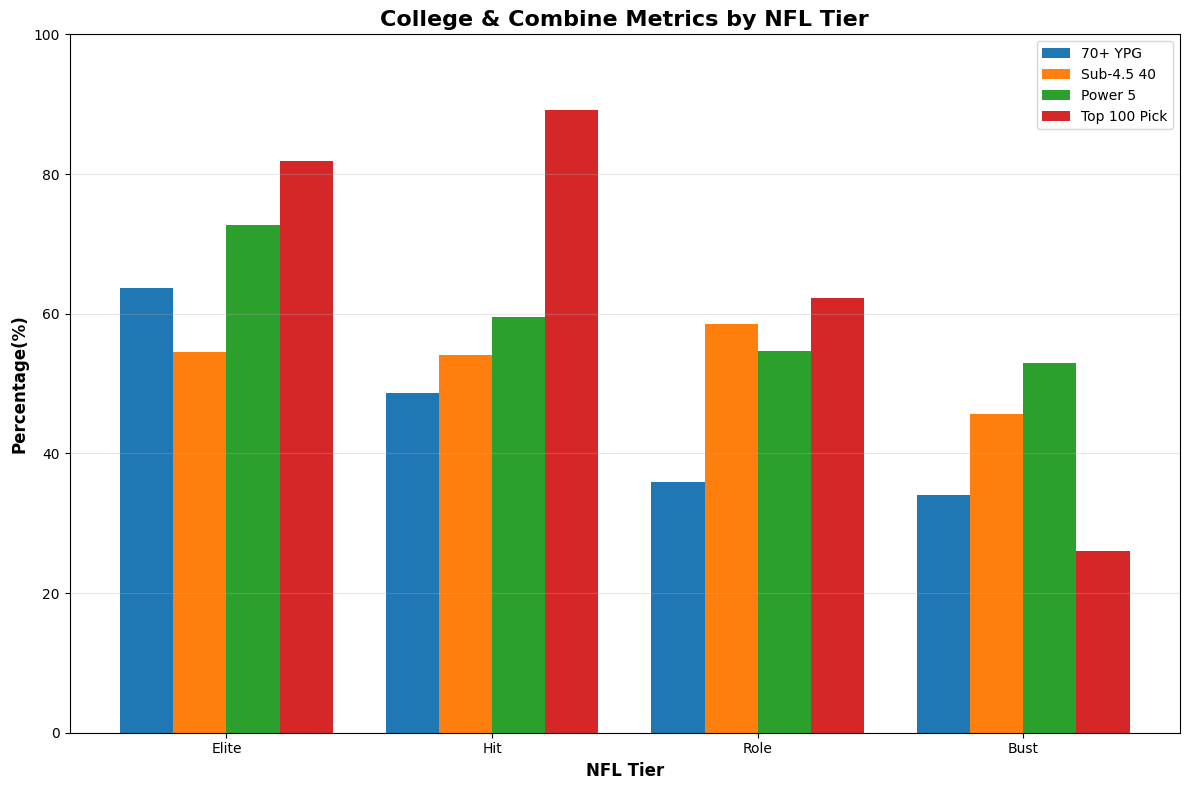


RAW PERCENTAGES BY TIER:
Tier          70+ YPG   Sub-4.5 40    Power 5    Top 100
----------------------------------------------------------------------
Elite            63.6%         54.5%       72.7%       81.8%
Hit              48.6%         54.1%       59.5%       89.2%
Role             35.8%         58.5%       54.7%       62.3%
Bust             34.1%         45.7%       52.9%       26.1%


In [18]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# visualization bar chart
tiers = ['Elite', 'Hit', 'Role', 'Bust']
tier_colors = ['#FFD700', '#C0C0C0', '#CD7F32', '#6B7280']


metrics = {
    '70+ YPG': [],
    'Sub-4.5 40': [],
    'Power 5': [],
    'Top 100 Pick': []
}

# calculate the percentages in each tier
for tier in tiers:
    tier_players = results[results['nfl_tier'] == tier]
    total = len(tier_players)

    if total > 0:
        metrics['70+ YPG'].append(100 * 
                len(tier_players[tier_players['college_ypg'] >= 70]) / total)
        metrics['Sub-4.5 40'].append(100 * 
                len(tier_players[tier_players['forty_time'] <= 4.5]) / total)
        metrics['Power 5'].append(100 * 
                len(tier_players[tier_players['conference_tier']
                .isin(['Top 2 Conferences', 'Power 5'])]) / total)
        metrics['Top 100 Pick'].append(100 * 
                len(tier_players[tier_players['Pick'] <= 100]) / total)
    else:
        for metric in metrics:
            metrics[metric].append(0)

    
# create grouped bar chart
x = np.arange(len(tiers))
width = 0.2
multiplier = 0

fig, ax = plt.subplots(figsize=(12,8))

for metric, values, in metrics.items():
    offset = width * multiplier
    bars = ax.bar(x + offset, values, width, label = metric)
    multiplier += 1

# labels and formatting
ax.set_xlabel('NFL Tier', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage(%)', fontsize=12, fontweight='bold')
ax.set_title('College & Combine Metrics by NFL Tier', fontsize=16, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(tiers)
ax.legend(loc='upper right')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tier_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nRAW PERCENTAGES BY TIER:")
print("=" * 70)
print(f"{'Tier':<10} {'70+ YPG':>10} {'Sub-4.5 40':>12} {'Power 5':>10} {'Top 100':>10}")
print("-" * 70)
for i, tier in enumerate(tiers):
    print(f"{tier:<10} {metrics['70+ YPG'][i]:>10.1f}% {metrics['Sub-4.5 40'][i]:>12.1f}% "
        f"{metrics['Power 5'][i]:>10.1f}% {metrics['Top 100 Pick'][i]:>10.1f}%")



***
### BIGGEST TAKEAWAYS
1. There isn't a super high bust rate inside of the top 100 <br>
Only about a quarter of busts in the NFL (according to my metrics) have come inside the top 100 picks. If you need a receiver, it is best to draft one inside those first three rounds. Outside of a top 100 pick, you have a 74% chance of a bust.

2. The Power 5 dominates receivers, especially Elite ones<br>
If you want an elite receiver, chances are you are going to need to look into a power five school. While around half of all other tiers of receivers come from power 5 schools, nearly three quarters of elite receivers come from Power 5 schools. This means if you want a guy who is going to be a number one wideout, you better do your research into power 5 programs. If you want a supplementary guy, getting one in a Power 5 matters much less.

3. 40 yard dash time is very undertiministic of NFL success <br>
In almost every tier, about half of NFL receivers have sub 4.5 40 times. The only somewhat extreme value is the bust category, in which only 45.7% of busts have a 40 time under or at 4.5. So there is a higher chance that a receiver will be a bust if they run slower than that, but not drastic. It might be worth taking a look at sub-4.4 guys.

4. College receiving production MATTERS<br>
One of the biggest factors that I noticed is that receivers with 70+ YPG was one of the biggest metrics (other than draft slot) that set elite/hit receivers apart. Well over half of the elite receivers averaged 70+ YPG (63.6%) and nearly half of the hit receivers did as well (48.6%). This category was significantly lower in the role/bust category, at 35.8% and 34.1% respectively. So if you want a guy that is more likely to be a hit or an elite guy, you might want to look at that ypg production after all.
***


### More Measurements
Now I want to look at a few more variables and compare them to my NFL success tiers. These are the new metrics we will look at.

1. **Cone Drill:** Agility/route-running (often separates slot guys)
2. **Broad Jump:** Explosiveness, power
3. **Peak College TDs:** Red zone production, dominance
4. **Yards/Reception:** Deep threat vs possession receiver

Before I make a hypothesis, I need to see some averages for each of these metrics, as I am less familiar with these then the last group

In [20]:
print("OVERALL AVERAGES FOR NEW METRICS")
print("=" * 60)

metrics = {
    'Cone Drill (seconds)': 'cone',
    'Broad Jump (inches)': 'broad_jump', 
    'Peak College TDs': 'peak_college_td',
    'Yards/Reception': 'yards_per_catch'
}

for label, col in metrics.items():
    avg = results[col].mean()
    median = results[col].median()
    min_val = results[col].min()
    max_val = results[col].max()
    
    print(f"\n{label}")
    print(f"  Average: {avg:.2f}")
    print(f"  Median:  {median:.2f}")
    print(f"  Range:   {min_val:.1f} - {max_val:.1f}")
    print(f"  Players with data: {results[col].count()}")

# Optional: Quick distribution view
print("\n" + "=" * 60)
print("QUICK DISTRIBUTION (25th, 50th, 75th percentiles):")
print(results[['cone', 'broad_jump', 'peak_college_td', 'yards_per_catch']].describe(percentiles=[.25, .5, .75]).round(2))

OVERALL AVERAGES FOR NEW METRICS

Cone Drill (seconds)
  Average: 6.97
  Median:  6.98
  Range:   6.6 - 7.4
  Players with data: 115

Broad Jump (inches)
  Average: 124.47
  Median:  124.00
  Range:   110.0 - 140.0
  Players with data: 200

Peak College TDs
  Average: 8.88
  Median:  8.00
  Range:   1.0 - 23.0
  Players with data: 222

Yards/Reception
  Average: 15.30
  Median:  15.18
  Range:   10.3 - 25.4
  Players with data: 222

QUICK DISTRIBUTION (25th, 50th, 75th percentiles):
         cone  broad_jump  peak_college_td  yards_per_catch
count  115.00      200.00           222.00           222.00
mean     6.97      124.48             8.88            15.30
std      0.20        5.77             3.52             2.50
min      6.56      110.00             1.00            10.30
25%      6.82      121.00             7.00            13.42
50%      6.98      124.00             8.00            15.18
75%      7.10      128.00            11.00            16.65
max      7.42      140.00       



With that information in mind, here are my hypotheses for each:
### Hypothesis
I believe that players who are considered elite in the NFL will satisfy these standards: <br>
1. **Cone Drill:** 6.9 seconds (better agility than the 6.97 average)
2. **Broad Jump:** 125 inches (above the 124.5 average, showing explosiveness)
3. **Peak College TDs:** ≥ 12 touchdowns (well above the 8.9 average, showing dominance)
4. **Yards/Reception:** 16.0 Y/R (above the 15.3 average, indicating deep threat ability)

Now time to test these hypotheses

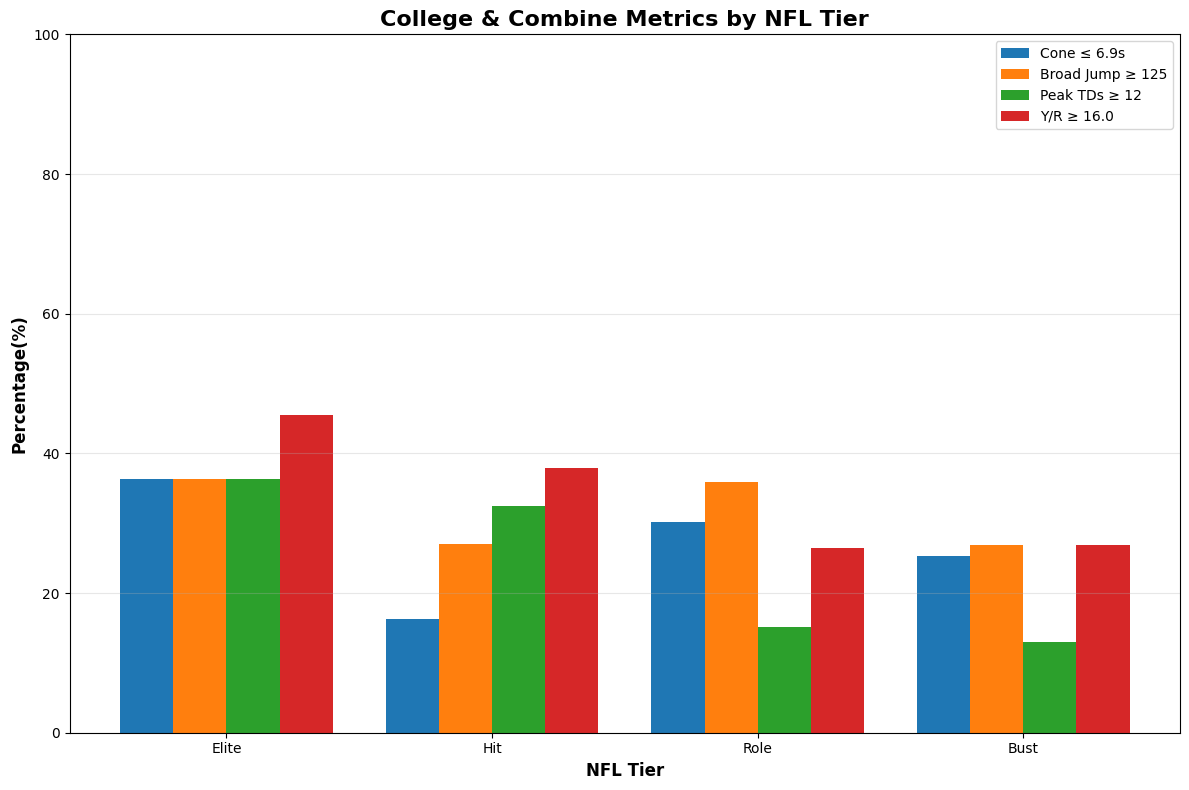


ADVANCED METRICS BY TIER:
Tier         Cone ≤6.9s  Broad Jump ≥125    TDs ≥12    Y/R ≥16.0
--------------------------------------------------------------------------------
Elite              36.4%             36.4%       36.4%         45.5%
Hit                16.2%             27.0%       32.4%         37.8%
Role               30.2%             35.8%       15.1%         26.4%
Bust               25.4%             26.8%       13.0%         26.8%


In [24]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# visualization bar chart
tiers = ['Elite', 'Hit', 'Role', 'Bust']
tier_colors = ['#FFD700', '#C0C0C0', '#CD7F32', '#6B7280']


metrics = {
    'Cone ≤ 6.9s': [],
    'Broad Jump ≥ 125': [],
    'Peak TDs ≥ 12': [],
    'Y/R ≥ 16.0': []
}

# calculate the percentages in each tier
for tier in tiers:
    tier_players = results[results['nfl_tier'] == tier]
    total = len(tier_players)

    if total > 0:
        metrics['Cone ≤ 6.9s'].append(100 * 
                len(tier_players[tier_players['cone'] <= 7]) / total)
        metrics['Broad Jump ≥ 125'].append(100 * 
                len(tier_players[tier_players['broad_jump'] >= 125]) / total)
        metrics['Peak TDs ≥ 12'].append(100 *
                len(tier_players[tier_players['peak_college_td'] >= 12]) / total)
        metrics['Y/R ≥ 16.0'].append(100 * 
                len(tier_players[tier_players['yards_per_catch'] >= 16]) / total)
    else:
        for metric in metrics:
            metrics[metric].append(0)

    
# create grouped bar chart
x = np.arange(len(tiers))
width = 0.2
multiplier = 0

fig, ax = plt.subplots(figsize=(12,8))

for metric, values, in metrics.items():
    offset = width * multiplier
    bars = ax.bar(x + offset, values, width, label = metric)
    multiplier += 1

# labels and formatting
ax.set_xlabel('NFL Tier', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage(%)', fontsize=12, fontweight='bold')
ax.set_title('College & Combine Metrics by NFL Tier', fontsize=16, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(tiers)
ax.legend(loc='upper right')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tier_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nADVANCED METRICS BY TIER:")
print("=" * 80)
print(f"{'Tier':<10} {'Cone ≤6.9s':>12} {'Broad Jump ≥125':>16} {'TDs ≥12':>10} {'Y/R ≥16.0':>12}")
print("-" * 80)
for i, tier in enumerate(tiers):
    print(f"{tier:<10} {metrics['Cone ≤ 6.9s'][i]:>12.1f}% {metrics['Broad Jump ≥ 125'][i]:>16.1f}% "
          f"{metrics['Peak TDs ≥ 12'][i]:>10.1f}% {metrics['Y/R ≥ 16.0'][i]:>12.1f}%")



***
### BIGGEST TAKEAWAYS
1. BIG TD PRODUCTION IS IMPORTANT <br>
WRs that put up big td production are proven to be in the Hit tier or above in the NFL. That is a stat that seems to translate. I measured a big number (12), so all tiers were less than 50%. But both Elite and Hit receivers had a season of 12+ TDs over 30% of the time (36.4% and 32.4%), while role and bust players were both at or below 15% (15.1% and 13.0%).

2. Yards/Reception more relevant than expected <br>
I expected yards/reception to be somewhat all over the place, but it seems like big time receivers make big time plays. Hit/Elite receivers separated themselves in this category, showing that players who made over 16 y/c showed up 11% to 19% more in each of these categories respectively than they did in the role/bust category. 

3. Teams put too much stock in 3 cone, but Elite receivers have Elite 3 cone times<br>
The three cone is where I had to do a little digging. It is very sporadic, showing that Elite receivers do often show elite 3 cone times, but a low percentage of Hit receivers do (only 16.2%). There is also often a lot of role receivers that have good 3 cone times (30.2%) and a decent number of busts who do as well (25.4%). What this shows me is that GMs put too much stock into it. Because so many stars have great 3 cone times, they automatically think you need a good time to be a good receiver. What my findings suggest is that if you have a good 3 cone time with good production, you are likely to have a great chance to be an elite receiver. But if you have an elite 3 cone time without that elite production, you are more likely to be a guy who can play a role in an offense, but more as a separator who creates space for the elite weapons of an offense. 

4. Broad Jump draws similar conclusions to 3 cone <br>
I think again here, we see that one of the lowest numbers of elite broad jump comes in hit receivers. This means that to be elite, you probably need to be an explosive athlete. But receivers who are elite athletes and subpar producers, are often subpar receivers in the NFL. They are often the guys who run clear out routes and don't necessarily produce at a high level once they are in the league

***
## LINKS <br>
#### [PORTFOLIO](https://quinng8.github.io/nfl-draft-analytics/)